In [1]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
import os
import pandas as pd
from datetime import datetime

os.chdir('../src/')

import make_files
import integrate

import prop_elem
import sbdynt

# Initializing a Small Body Object

SBDynT is built around small_body objects, which can be used to simulate and dynamically analyze Solar System Small Bodies.

A small_body object for which proper elements will be comptued is primarily initialized using two variables: 

    (1) designation (str): This is the designation of the small body you want to analyze. This designation will be used to request orbital information form the MPC by way of JPL Horizons, so make sure that the designation you choose is a valid id which can effectively query the JP Horizons database.

    (2) object_type (str): Currently there are two acceptable values for this variable, 'tno' and 'asteroid'. Using the appropriate object_type will allow SBDynT to use accurate default settings for integration length and output schema. 

Some additional variables that can be defined by the user include:

    (3) clones (int): The number of clones you want to include in your integration. Default = 0.

    (4) savefile (boolean): Whether or not you want to save the initialization simulation produced for your integrations to a binary file. Default = False.

    (5) filetype (str): The output folder in the ``data`` directory for your integration data. Default: 'Single', indicating that this object is analyzed by itself, rather than in some collection of objects.

### Initialization example
We show an example of initializing small_body objects for the dwarf planets ``Ceres`` and ``Eris``. We define the ceres particle as an asteroid, and the eris particle as a tno. We also define savefile as True to save the relevant files.

In [3]:
ceres = sbdynt.small_body('Ceres',object_type = 'asteroid', savefile = True)
eris = sbdynt.small_body('Eris',object_type = 'tno', savefile = True)

The initialization of the particle does very little, and produces no outputs to begin with. 

# Computing Default Proper Elements
The proper elements can be computed using default settings by calling the ``run_pe`` function as so. This will produce integrations long enough to capture the secular motion of the small body, and will perform the filtering process described in Spencer et al. 2026. 

The default location for saving these integrations will be ``SBDynT/data/Single/*designation*/archive.bin``.

The full integrations can take some time to run, and so we restrict the time of the simulations to be 1/10 of the default length for speed in this notebook. However, this function may be called as an empty function call to perform the full default run for the objects.

In [4]:
ceres.run_pe(tmax=1e6)
eris.run_pe(tmax=1.5e7)

Adding:  {2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
Integration Completed; run took  0:04:19.094671  seconds.
Proper Elements: {'a': 2.7670929095866574, 'e': 0.11313852081271757, 'sinI': 0.16751120957460094, 'omega': 1.4834165969253768, 'Omega': 1.372912384207507, 'g': 54.40487173806776, 's': -59.58628809407421}
Adding:  {5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
Integration Completed; run took  0:02:57.778351  seconds.
Proper Elements: {'a': 67.92957009254921, 'e': 0.018993399718436835, 'sinI': 0.3875997279346118, 'omega': 0.704613920934294, 'Omega': 0.6544218877155764, 'g': -0.0863713319222741, 's': -0.4318566596113705}


# Advanced Proper Element Computation
To compute synthetic proper elements in a more hands-on approach, the user can produce an initial REBOUND simulation of the Solar System themselves, perform the integration, and then compute the proper elements themselves. 

This can be done by calling the 3 underlying functions called by ``run_pe``, namely ``init_pe``, ``integrate``, and then ``compute_proper``. These functions have a number of defualt settings that the user may wish to define themself.

### Simulation Initialization

Print statements indicate which planets have been included in the simulation. The default case for an asteroid is to include every planet besides Mercury in the simulation, and the default for a tno is to include just the 4 gas giants. These default planet settings can be accessed by simply keeping the default ``planets = None``. Additional settings are shown below.



In [3]:
ceres.init_pe(planets=None, filename='Single')
eris.init_pe(planets=None, filename='Single')

Adding:  {2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
Adding:  {5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}


Note that since we have defined ``savefile`` as True for the ceres and eris particles, new directories have been created in "SBDynT/data/Single" representing each obejct. This directory will contain the binary files related to the analysis. 
Indeed, with the intiialization, you should see new ``archive_init.bin`` files populated within the Ceres and Eris directories. 

If ``savefile`` were left as False, the directories would be created, but the ``archive_init.bin`` files would not, as the simulation would be stored natively within the small_body object.

These files will be used to run all of the integrations in our analysis.

The user may also define two variables in the ``init_pe`` function call if they wish...

    (1) planets (None, int=(1,2,3), or dict)         default: None
            This variable can be defined in 3 ways. 
            
            None: SBDynT uses the default planet configuration for the ``object_type`` of the small_body.
            1: simulation planets = {2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
            2: simulation planets = {5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
            3: simulation planets = {1: 'mercury', 2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
            dict: The user may define their own planet configuration by following the format of the dictionaries shown above. Example: planets = {8: 'neptune'} would initialize the simulation with the Sun, Neptune, and the small body. This type of configuration may be relevant for very detached TNOs which the user wishes to integrate for very long timescales. 

            Support also exists for users to include the masses of Ceres (9), Vesta (10), and Pluto (11) if the user wishes. To do so, the user should define the planets dictionary themselves, and include the dwarf planet and associated number in SBDynT's ecosystem.

            Examples: 
            eris.init_pe(planets={5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune', 11: 'pluto'}, filename='Single')
            psyche.init_pe(planets={2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune', 9:'ceres', 10:'vesta'}, filename='Single')
    
    (2) filename (str)                               default: 'Single'
            This variable defines the direcotry where data should be stored for the integration. Example: filename = 'Single' will save REBOUND archive binary files in data/Single/``designation``/.

# KV: Do we provide support for including Ceres, Vesta, or Pluto, which are relevant to some users? I added the GM's as reported in Park 2021 for Ceres, Vesta, and Pluto to hard_coded_constants if so.

In [6]:
psyche = sbdynt.small_body('Psyche',object_type = 'asteroid', savefile = True)
psyche.init_pe(planets={2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}, filename='Single')
psyche.integrate(tmax = 1e5, tout=None, direction='both', deletefile=True)

Adding:  {2: 'venus', 3: 'earth', 4: 'mars', 5: 'jupiter', 6: 'saturn', 7: 'uranus', 8: 'neptune'}
planets: ['venus', 'earth', 'mars', 'jupiter', 'saturn', 'uranus', 'neptune']
Integration Completed; run took  0:00:11.924188  seconds.


In [8]:
psyche.sim_init.particles['Psyche']
#psyche.sim_init.particles['vesta']
#len(psyche.sim_init.particles)

<rebound.particle.Particle object at 0x2294b8cd750, m=0.0 x=-2.6164870306767787 y=1.6630056824559236 z=-0.09003698761633833 vx=-2.163804359992148 vy=-2.6959400190524403 vz=0.04487456550169703>

# Running the Integration

Now that our simulations are initialized, we can run the integration using the ``integrate`` function.

Again, default settings allow the user to simply call the function, which will automatically set values such as the integration length and output resolution. 

However, the user may wish to set some vairbales themselves. The integrate function has 4 variables the user can set:

    (1) tmax (float)           units: yr     default: asteroids=1e7 ; tnos = 1.5e8
        - tmax is the total length of the integration in Earth years you want to run for. 
        
    (2) tout (float)           units: yr     default: asteroids=500 ; tnos = 5000
        - tout is the output cadence you wish to save the data in. Example: tout = 500 would save the orbital state every 500 years. For a 10 Myr integration, this would equate to 20,001 total outputs, including t=0.
        
    (3) direction (str)                      default: 'both'          options = 'forwards', 'backwards', 'both'
        - The direction of the integration. 'both' produces both a backwards and a forwards integration, integrating the particle for 1/2 of the tmax in each direction. 
        
    (4) deletefile (boolean)                  default: True
        - This variable tells the REBOUND integrator whether to delete any files of the same name. Users who may have had a failure during an integration may set this to True to start the integration at the same point that it originally failed. 

We show examples integrating both Ceres and Eris, setting tmax for shorter times, as the full integration takes 10's of minutes. 

In [8]:
ceres.integrate(tmax = 1e5, tout=None, direction='both', deletefile=True)
eris.integrate(tmax = 1e6, tout=None, direction='both', deletefile=True)

The particle was likely ejected, or some other break point occurred within the Rebound integration. Simulation ended.
Integration Completed; run took  0:00:00.001000  seconds.
Integration Completed; run took  0:01:37.713441  seconds.


Once the integration is complete, SBDynT automatically reads the orbital elements into the small_body. These can be accessed by calling the ``a_arr, e_arr, I_arr, o_arr, O_arr and M_arr`` variables. In addition, the time array is saved as ``t_arr``.

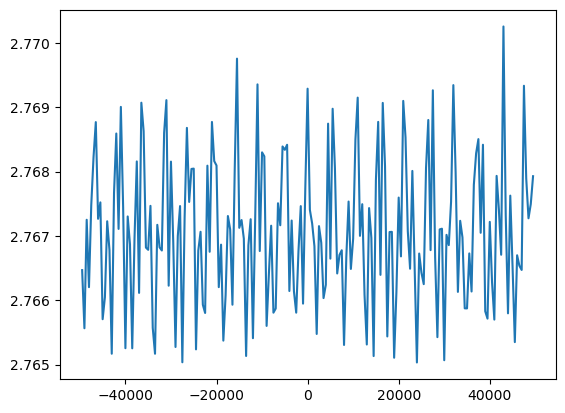

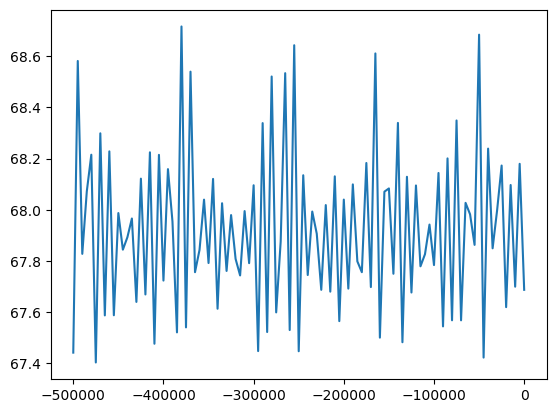

In [9]:
plt.plot(ceres.t_arr, ceres.a_arr)
plt.show()
plt.plot(eris.t_arr, eris.a_arr)
plt.show()

# Computing Synthetic Proper Elements

To compute synthetic proper elements for the small_body the typical user will simply call the ``compute_proper`` function, as shown below.
The function call will print the comptued proper elements out; additional outputs, such as the uncertainties, are saved to the particle and can be retrieved directly. 

In [10]:
ceres.compute_proper(windows=5, time_run = 0, rms = True, debug = False)
eris.compute_proper(windows=5, time_run = 0, rms = True, debug = False)

Proper Elements: {'a': 2.7670929095866574, 'e': 0.11313852081271757, 'sinI': 0.16751120957460094, 'omega': 1.4834165969253768, 'Omega': 1.372912384207507, 'g': 54.40487173806776, 's': -59.58628809407421}
attempt to get argmax of an empty sequence
Gathering planetary frequencies failed
An error occurred in at line 1178
An error occurred in at line 1394
'int' object is not subscriptable


ValueError: not enough values to unpack (expected 21, got 20)

In [ ]:
print(ceres.proper_elements)
print(ceres.proper_errors)